# Group Project: Generalisable ECG

Saumya Roy, MSc Data-Driven Health, CM2011 <br>
Yuxin Du, MSc Data-Driven Health, CM2011

## Imports

> ✅ Run this

In [18]:
from pathlib import Path
from torch.utils.data import DataLoader
from utility_functions import *



## Load data and plot missingness

> ✅ Run this

### PTB:

______________________________________________________________________
PTB-XL metadata
______________________________________________________________________
Shape: (21799, 32)

Columns:
['ecg_id', 'patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr', 'scp_codes_dict', 'n_scp_codes', 'record_base_100', 'record_base_500']

Dtypes:
ecg_id                            int64
patient_id                      float64
age                             float64
sex                               int64
height                          float64
weight                          float64
nurse                           float64
site                            fl

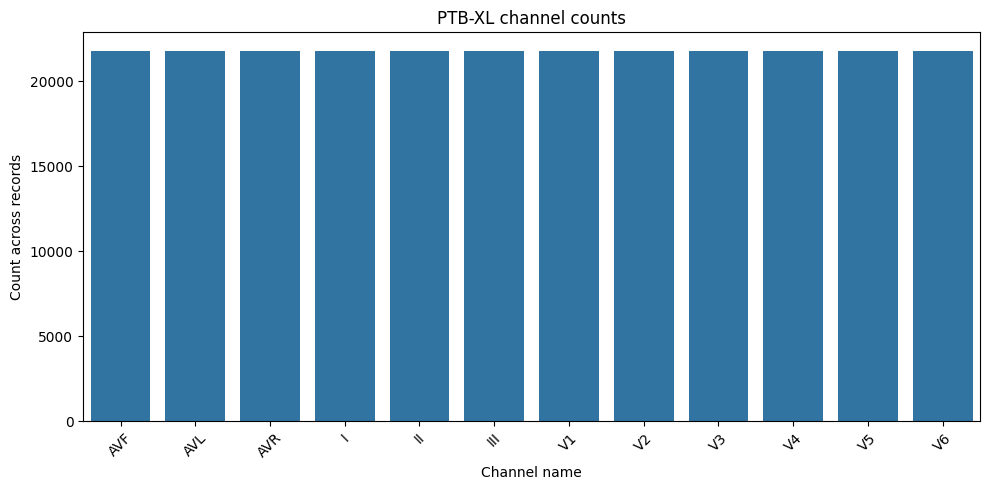

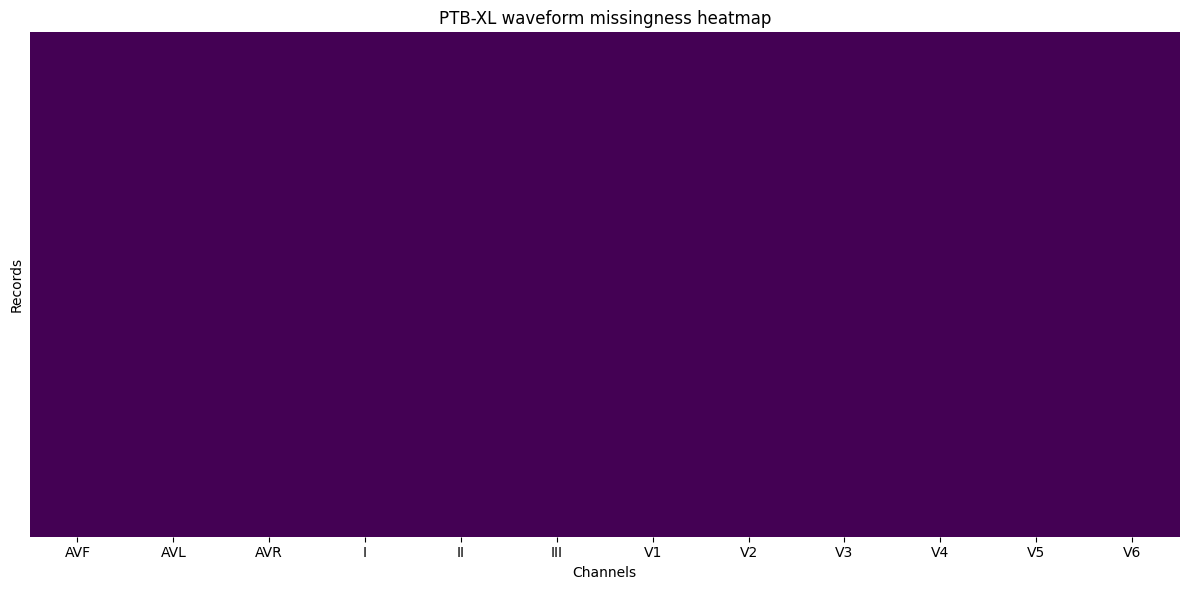

In [19]:
# raw data path
PTB_ROOT = Path("ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3")
LTDB_ROOT = Path("mit-bih-long-term-ecg-database-1.0.0")


# load ptb-xl metadata
ptb_df = load_ptb_metadata(PTB_ROOT)
print_basic_df_info(ptb_df, "PTB-XL metadata")

# examine missingness and channel stats of ptb-xl metadata
ptb_wave_missingness, ptb_channel_stats, ptb_channel_level = missingness_report(
    ptb_df,
    record_base_col="record_base_100",
    dataset_name="PTB-XL"
)


In [20]:
# Add 5 diagnositic superclass targets to the ptb dataset
scp_df = load_ptb_scp_mapping(PTB_ROOT)
ptb_df = add_ptb_superclass_targets(ptb_df, scp_df)

print_basic_df_info(
    ptb_df[
        [
            "ecg_id", "patient_id", "strat_fold", "age", "sex",
            "n_scp_codes", "superclasses", "NORM", "MI", "STTC", "CD", "HYP"
        ]
    ],
    "PTB-XL with superclass targets"
)


______________________________________________________________________
PTB-XL with superclass targets
______________________________________________________________________
Shape: (21799, 12)

Columns:
['ecg_id', 'patient_id', 'strat_fold', 'age', 'sex', 'n_scp_codes', 'superclasses', 'NORM', 'MI', 'STTC', 'CD', 'HYP']

Dtypes:
ecg_id            int64
patient_id      float64
strat_fold        int64
age             float64
sex               int64
n_scp_codes       int64
superclasses     object
NORM              int64
MI                int64
STTC              int64
CD                int64
HYP               int64
dtype: object

First 5 rows:
   ecg_id  patient_id  strat_fold   age  sex  n_scp_codes superclasses  NORM  \
0       1     15709.0           3  56.0    1            3       [NORM]     1   
1       2     13243.0           2  19.0    0            2       [NORM]     1   
2       3     20372.0           5  37.0    1            2       [NORM]     1   
3       4     17014.0           3

### LTDB:

______________________________________________________________________
LTDB summary
______________________________________________________________________
Shape: (7, 13)

Columns:
['record_id', 'record_base', 'fs', 'sig_len', 'duration_sec', 'duration_min', 'n_channels', 'sig_names', 'units', 'comments', 'n_annotations', 'unique_annotation_symbols', 'top_annotation_symbols']

Dtypes:
record_id                     object
record_base                   object
fs                             int64
sig_len                        int64
duration_sec                 float64
duration_min                 float64
n_channels                     int64
sig_names                     object
units                         object
comments                      object
n_annotations                  int64
unique_annotation_symbols      int64
top_annotation_symbols        object
dtype: object

First 5 rows:
  record_id                                 record_base   fs   sig_len  \
0     14046  mit-bih-long-ter

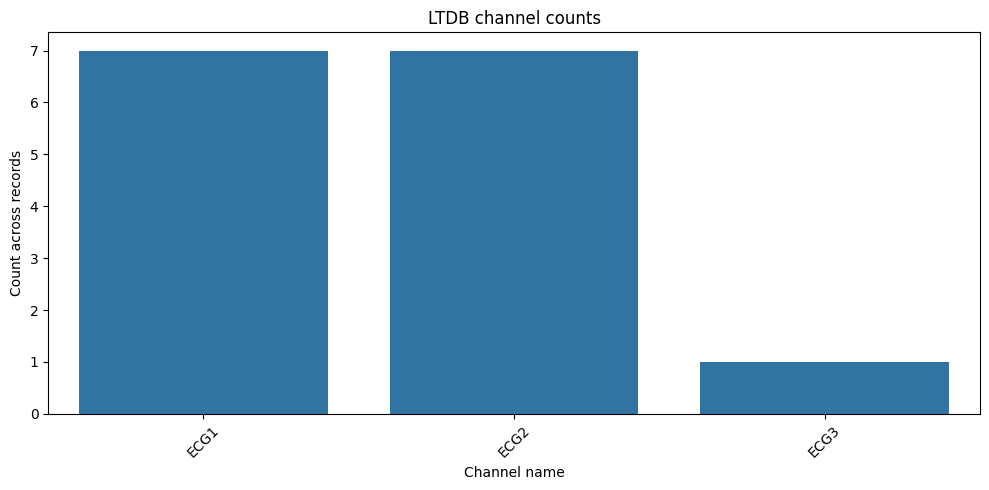

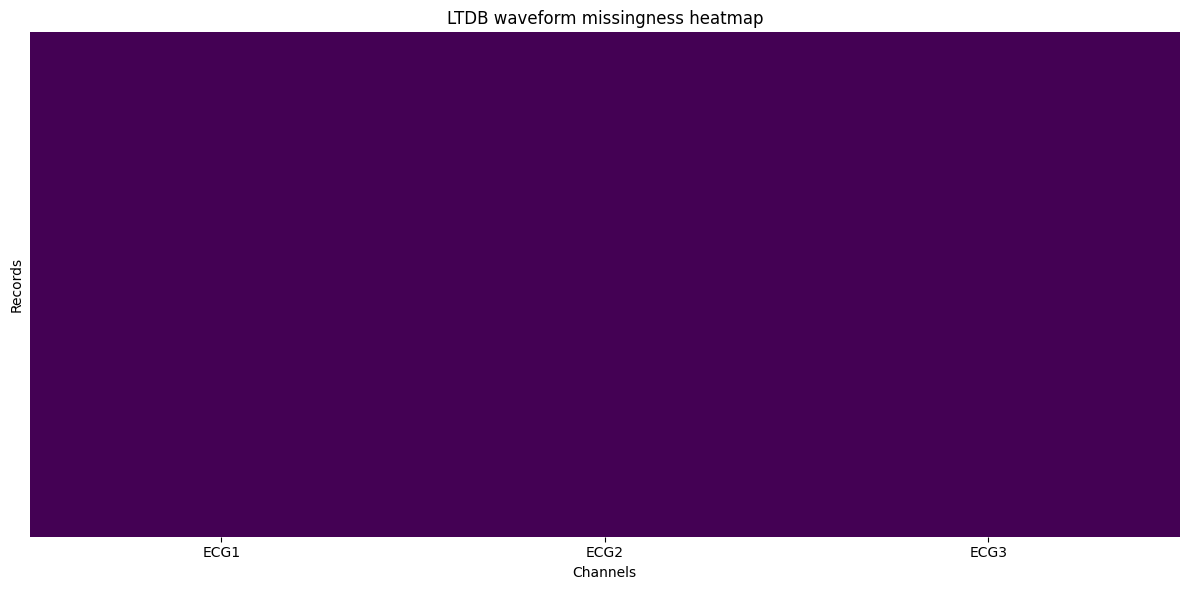

In [21]:
# load metadata of LTDB
ltdb_df = build_ltdb_summary_df(LTDB_ROOT)
print_basic_df_info(ltdb_df, "LTDB summary")

ltdb_wave_missingness, ltdb_channel_stats, ltdb_channel_level = missingness_report(
    ltdb_df,
    record_base_col="record_base",
    dataset_name="LTDB"
)



From the missing value plots, we can see there is no missing value hence no need for imputation. However, the LTDB dataset does not specify which leads do ECG1, ECG2 and ECG3 corresponds to.

## Visualise and explore data

Showing some metadata distribution of the PLT-XL dataset:


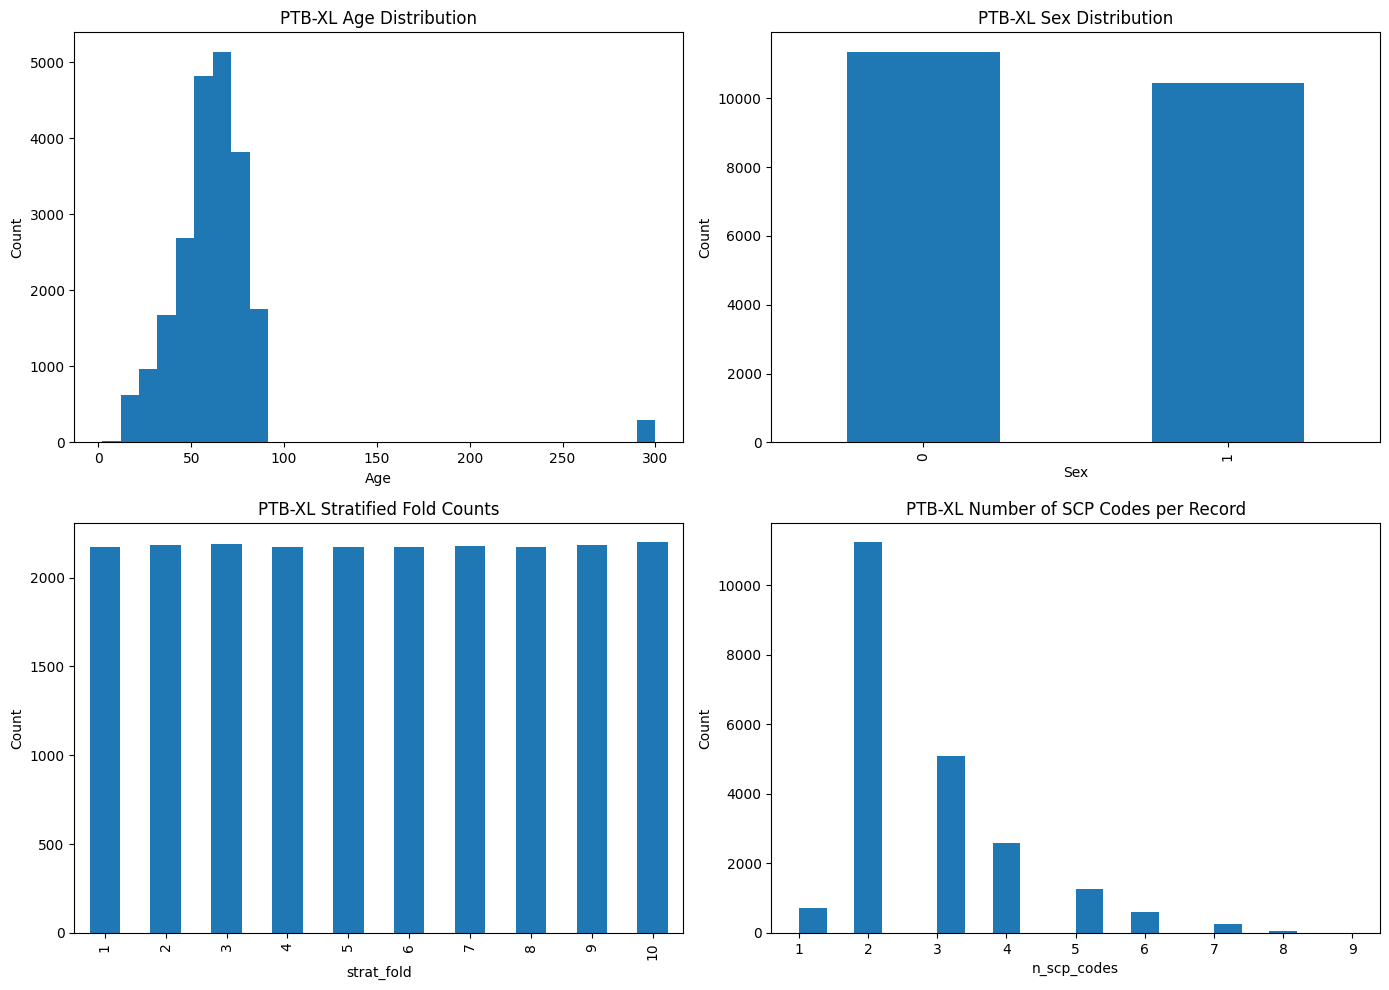

Diagnostic superclass count for PLT-XL dataset:


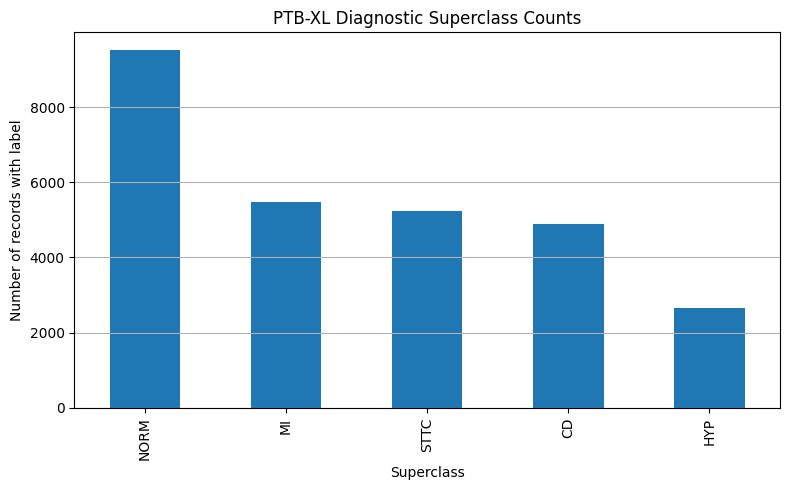

Overview of the LTDB dataset:


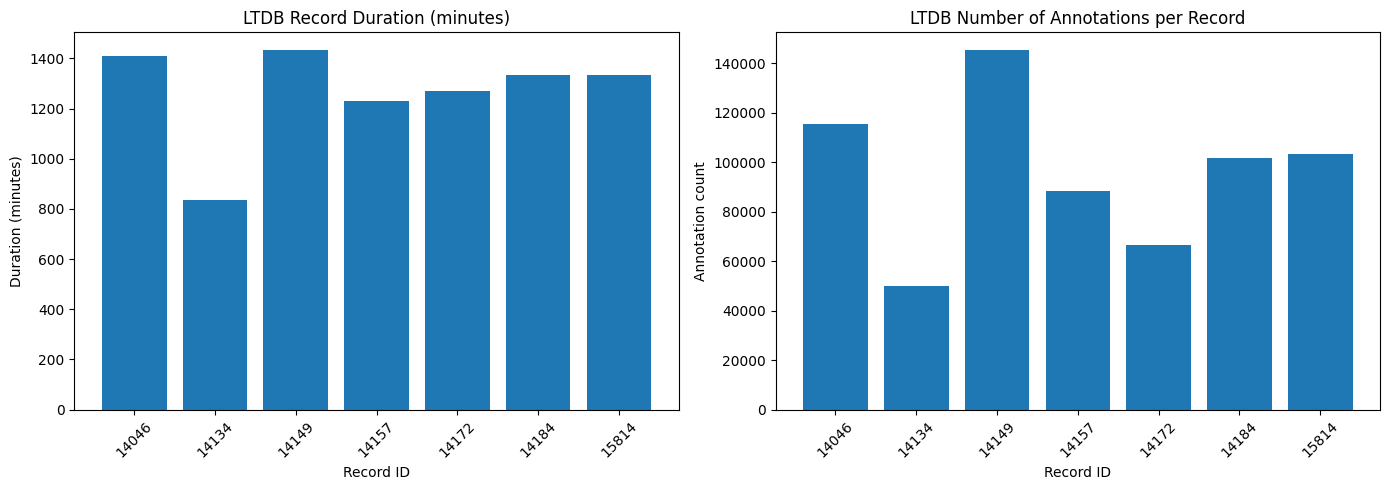

Example PTB record: ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\records100\00000\00001_lr


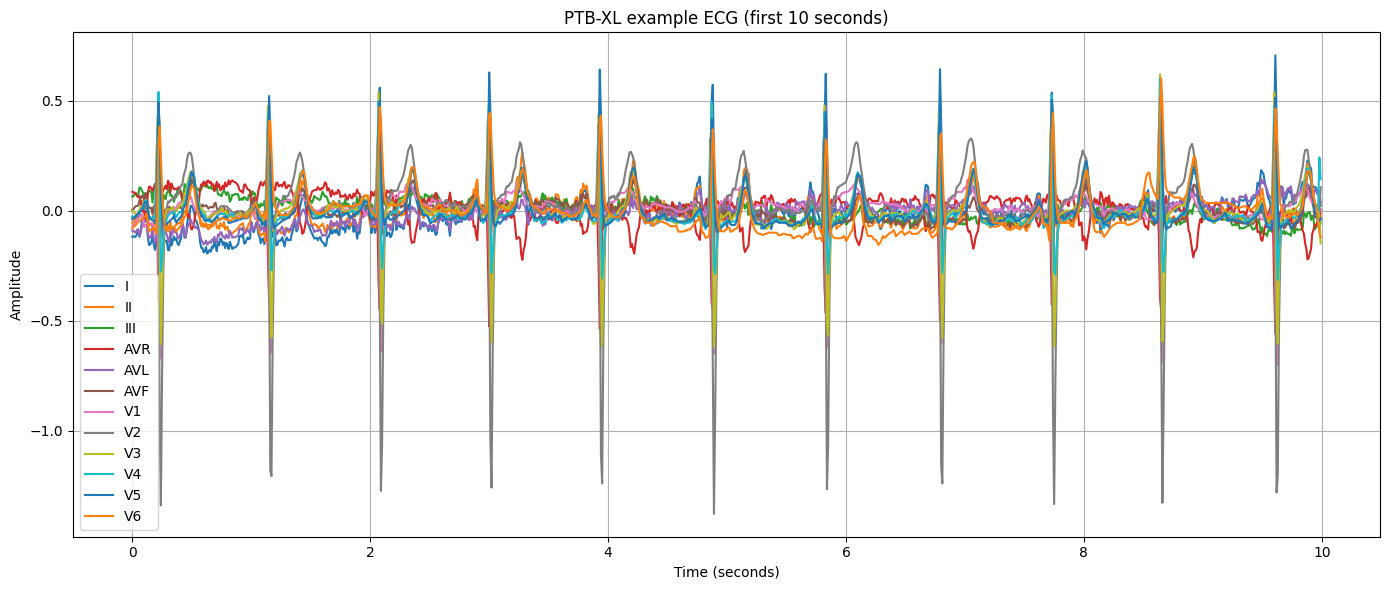

Example LTDB record: mit-bih-long-term-ecg-database-1.0.0\14046


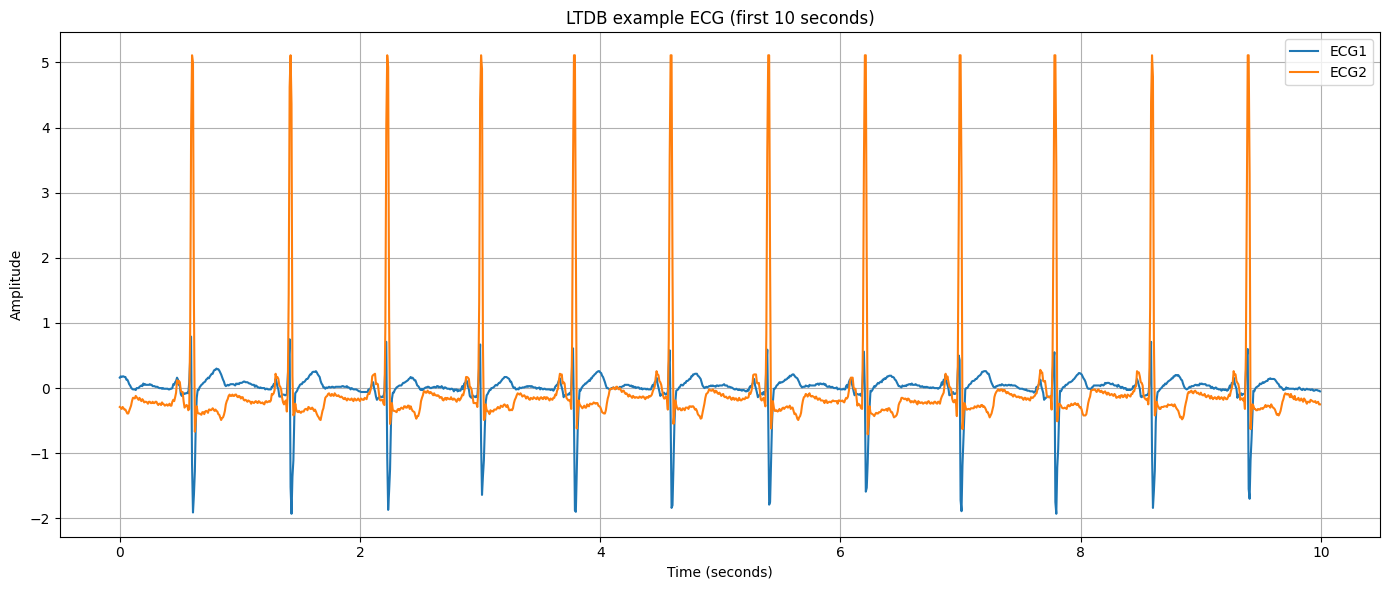

showing one channel of the LTDB example record with annotations


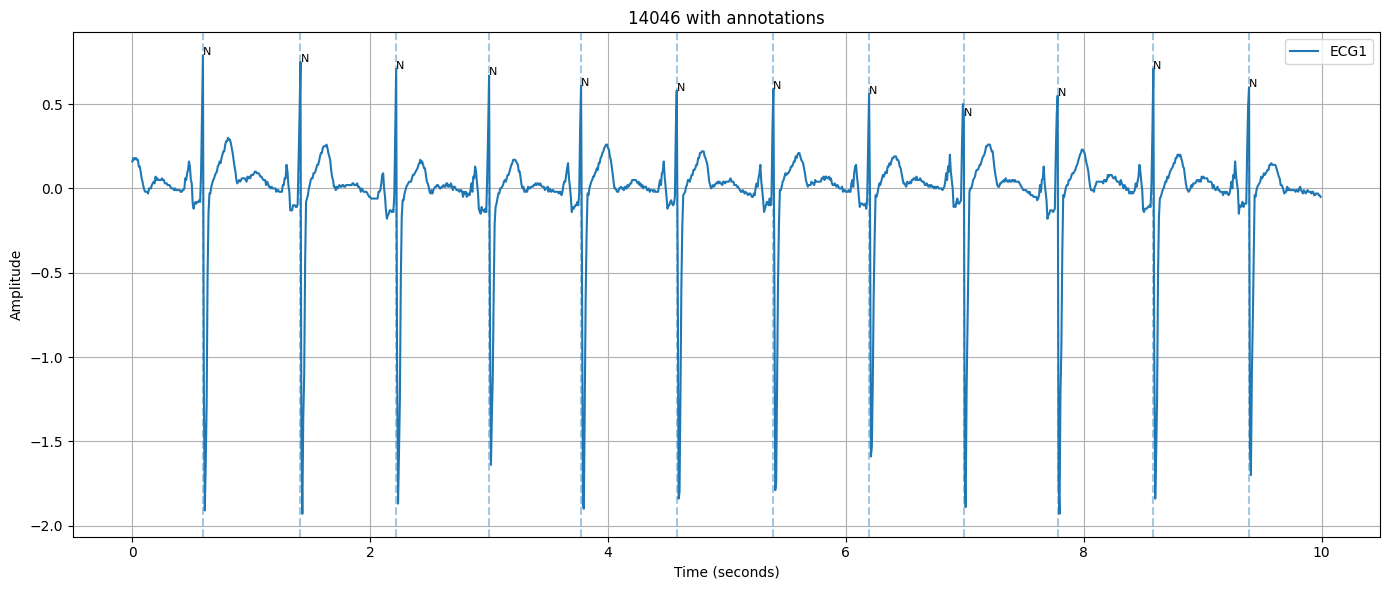

In [22]:
# visualise metadata distribution
print("Showing some metadata distribution of the PLT-XL dataset:")
plot_ptb_metadata_overview(ptb_df)
print("Diagnostic superclass count for PLT-XL dataset:")
plot_ptb_superclass_counts(ptb_df)
print("Overview of the LTDB dataset:")
plot_ltdb_record_overview(ltdb_df)

# PTB signals example
example_ptb_record = ptb_df.iloc[0]["record_base_100"]
print("Example PTB record:", example_ptb_record)
plot_ecg_record(
    record_base=example_ptb_record,
    title="PTB-XL example ECG (first 10 seconds)",
    start_sec=0.0,
    seconds=10.0
)


ltdb_record_ids = get_ltdb_record_ids(LTDB_ROOT)
example_ltdb_record = str(LTDB_ROOT / ltdb_record_ids[0])
print("Example LTDB record:", example_ltdb_record)

plot_ecg_record(
    record_base=example_ltdb_record,
    title="LTDB example ECG (first 10 seconds)",
    start_sec=0.0,
    seconds=10.0
    )

print("showing one channel of the LTDB example record with annotations")
plot_ecg_with_annotations(
    record_base=example_ltdb_record,
    ann_ext="atr",
    start_sec=0.0,
    seconds=10.0
)





Note that age above 89 is marked as 300 to comply with HIPAA de-identification rules by the dataset. Judging from the distribution of the diagnositic superclass labels, class imbalance needs to be handled later.

## Training strategy
Train a encoder that can turn a ECG channel regardless of its lead to a representation. After training the encoder, train prediction heads for PTB and LTDB separately. Apply encoder for each channel in a record, fuse the representations of the channels of one record, and then feed to prediction head.

## Data propressessing for training a encoder

In [27]:

TARGET_FS = 100 # all data will be resampled to this frequency

PRETRAIN_SECONDS = 5.0 # signal length used to train encoder


PTB_LABEL_COLS = ["NORM", "MI", "STTC", "CD", "HYP"]


# train, val, test splits
ptb_train_df, ptb_val_df, ptb_test_df = make_ptb_splits(ptb_df)
ltdb_train_ids, ltdb_val_ids, ltdb_test_ids = make_ltdb_split(ltdb_record_ids, seed=42)

print("LTDB train:", ltdb_train_ids)
print("LTDB val:  ", ltdb_val_ids)
print("LTDB test: ", ltdb_test_ids)


# prepare training data for training the encoder
ptb_pretrain_ds = PTBPretrainSingleChannelDataset(
    ptb_train_df,
    target_fs=TARGET_FS,
    seconds=PRETRAIN_SECONDS,
    use_filter=True
)

ltdb_pretrain_ds = LTDBPretrainSingleChannelDataset(
    LTDB_ROOT,
    ltdb_train_ids,
    target_fs=TARGET_FS,
    seconds=PRETRAIN_SECONDS,
    samples_per_epoch=4000,
    use_filter=True
)

pretrain_ds = BalancedPretrainDataset(
    ptb_ds=ptb_pretrain_ds,
    ltdb_ds=ltdb_pretrain_ds,
    p_ptb=0.5,
    samples_per_epoch=8000
)

pretrain_loader = DataLoader(
    pretrain_ds,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    collate_fn=mae_collate_fn
)

# prepare validation data for training the encoder
ptb_pretrain_val_ds = PTBPretrainSingleChannelDataset(
    ptb_val_df,
    target_fs=TARGET_FS,
    seconds=PRETRAIN_SECONDS,
    use_filter=True
)

ltdb_pretrain_val_ds = LTDBPretrainSingleChannelDataset(
    LTDB_ROOT,
    ltdb_val_ids,
    target_fs=TARGET_FS,
    seconds=PRETRAIN_SECONDS,
    samples_per_epoch=400,
    use_filter=True
)

pretrain_val_ds = BalancedPretrainDataset(
    ptb_ds=ptb_pretrain_val_ds,
    ltdb_ds=ltdb_pretrain_val_ds,
    p_ptb=0.5,
    samples_per_epoch=800
)

pretrain_val_loader = DataLoader(
    pretrain_val_ds,
    batch_size=64,
    shuffle=False,
    num_workers=0,
    collate_fn=mae_collate_fn
)

LTDB train: ['14134', '14157', '14172', '14149', '15814']
LTDB val:   ['14046']
LTDB test:  ['14184']


In [26]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNNTransformerMAE(
    signal_len=500,
    patch_size=25,
    stem_dim=64,
    enc_dim=128,
    dec_dim=128,
    enc_layers=6,
    enc_heads=4,
    dec_layers=4,
    dec_heads=4,
    mlp_ratio=4.0,
    dropout=0.1,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)
num_epochs = 150



best_val_loss = float("inf")
best_state = None

for epoch in range(1, num_epochs + 1):
    train_stats = run_pretrain_epoch(model, pretrain_loader, optimizer, device, train=True)
    val_stats = run_pretrain_epoch(model, pretrain_val_loader, optimizer=None, device=device, train=False)

    print_pretrain_stats(epoch, train_stats, val_stats)

    if val_stats["loss"] < best_val_loss:
        best_val_loss = val_stats["loss"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
  
# restore best model if you want
if best_state is not None:
    model.load_state_dict(best_state)

torch.save(model.state_dict(), "pretrained_cnn_transformer_mae.pt")
print("Saved pretrained model to pretrained_cnn_transformer_mae.pt")


Epoch 001 | train_loss=1.0564 | train_mae=0.6067 | train_rmse=1.0236 | train_r2=-0.0696 | train_corr=0.0059 | feat_std=0.1301 | PTB_mse=1.0403 | LTDB_mse=1.0723 || val_loss=1.0025 | val_mae=0.5218 | val_rmse=1.0011 | val_r2=-0.0028 | val_corr=0.0305
Epoch 002 | train_loss=0.9855 | train_mae=0.5755 | train_rmse=0.9926 | train_r2=-0.0054 | train_corr=0.0603 | feat_std=0.3945 | PTB_mse=0.9836 | LTDB_mse=0.9874 || val_loss=0.9817 | val_mae=0.5142 | val_rmse=0.9906 | val_r2=0.0082 | val_corr=0.0932
Epoch 003 | train_loss=0.9762 | train_mae=0.5702 | train_rmse=0.9879 | train_r2=0.0055 | train_corr=0.0932 | feat_std=0.4469 | PTB_mse=0.9680 | LTDB_mse=0.9842 || val_loss=0.9974 | val_mae=0.5214 | val_rmse=0.9984 | val_r2=0.0052 | val_corr=0.0874
Epoch 004 | train_loss=0.9799 | train_mae=0.5709 | train_rmse=0.9897 | train_r2=0.0101 | train_corr=0.1078 | feat_std=0.5152 | PTB_mse=0.9655 | LTDB_mse=0.9943 || val_loss=0.9797 | val_mae=0.5256 | val_rmse=0.9897 | val_r2=0.0138 | val_corr=0.1191
Epoch